# Human Study Question Sampling

Samples **100 questions** for the human study from the 1K VQA control set,
stratified by entity group × operator group (3×3, equal quota).


**Output:** `analysis/csv/human_study_sample.csv`


In [35]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR    = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()

# Full 5-step degradation ladder (pronominalized now complete for all models below)
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
# Degradation endpoint for Tier D/E (full pronoun ablation — steepest drop)
ABLATED_KEY   = 'pronominalized'

# Models with complete vqa_1k_control.jsonl (all 5 CONTROL_TYPES, 1000 records).
# Incomplete: Qwen3-VL-8B (only pronominalized), llava-v1.6-mistral-7b-hf (12 recs), Qwen3-VL-32B (43 recs)
COMPLETE_MODELS = [
    'InternVL3_5-1B',
    'InternVL3_5-2B',
    'InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
    'llava-1.5-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'llava-v1.6-vicuna-7b-hf',
]

sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = dict(zip(sem_df['question_id'], sem_df['ent']))
qid_to_op  = dict(zip(sem_df['question_id'], sem_df['op']))


---

## Ent × Op Stratified Sampling — Signal-Ranked Design

### Design decisions

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| N | **100** | 300 items/rater at 3 variants; fits ~1h session |
| Stratification | **3×3 ent_grp × op_grp** | Ensures entity and operator diversity; 11–12 Qs/cell |
| Quota | **Equal per cell** | No cell dominates; 3×3 gives all cells 11–12 (no pool capping at N=100) |
| Ranking within cell | **Priority → signal_score ↓** | Selects questions with strongest degradation signal first |
| Signal score | `0.5·acc_range + 0.3·acc_std + 0.2·n_unique` | acc_range = effect size (orig→pron); acc_std = curve gradualness; n_unique = output instability across models |
| Flat removal | Questions where all 5 control texts identical | Zero degradation signal — uninformative |

### Group definitions

**Ent (3):** `object` · `person` · `other_ent` (animal + food + place + vehicle + other + text + product)

**Op (3):** `attr` · `count` · `other_op` (exist + spat + ident + act + know + comp + cause + temp + text + other)

### Why 3×3 and not 5×5

The 5×5 grid has multiple cells capped at 5–10 questions (e.g. `other×count = 5`), making equal quotas unachievable. Collapsing to 3×3 raises all cell pools above 24, so N=100 → 11/cell with no capping.
The 3×3 stratification provides **coverage diversity** for the correlation analysis; it is not intended as an inferential grouping.


In [36]:
from utils.vqa import VQAAnswerMapper, vqa_accuracy
from collections import defaultdict

mapper = VQAAnswerMapper()

# ── Group mappings ──────────────────────────────────────────────────────────
ENT_COLLAPSE = {
    'object': 'object', 'person': 'person', 'animal': 'animal',
    'food': 'scene',    'place': 'scene',   'vehicle': 'scene',
    'other': 'other',   'text': 'other',    'product': 'other',
}
OP_COLLAPSE = {
    'attr': 'attr',    'count': 'count',
    'exist': 'local',  'spat': 'local',
    'ident': 'recog',  'act': 'recog',
    'text': 'other_op','know': 'other_op','comp': 'other_op',
    'cause': 'other_op','temp': 'other_op','other': 'other_op',
}

# ── Load control + inst_blind for all 8 complete models ─────────────────────
# Signal score is based on inst_blind (no image + instruction) — the condition
# used in the human study. High inst_blind accuracy = strong linguistic prior.
print('Loading control and inst_blind logits for 8 complete models...')

acc_by      = defaultdict(lambda: defaultdict(list))  # qid -> ct -> [acc, control]
acc_inst_by = defaultdict(lambda: defaultdict(list))  # qid -> ct -> [acc, inst_blind]
out_sets      = defaultdict(set)   # answer diversity across CTs+models (control)
out_sets_inst = defaultdict(set)   # answer diversity (inst_blind)
flat_ck = {}

for m in COMPLETE_MODELS:
    # control
    path = f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl'
    n = 0
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            ga  = ex.get('generated_answers', {})
            gt  = mapper.get_answers(qid)
            if qid not in flat_ck:
                flat_ck[qid] = {ex.get(ct,'').strip().lower() for ct in CONTROL_TYPES if ex.get(ct)}
            for ct in CONTROL_TYPES:
                out = ga.get(ct, '').strip()
                acc_by[qid][ct].append(vqa_accuracy(out, gt))
                out_sets[qid].add(out.lower())
            n += 1
    # inst_blind
    path_inst = f'{RESULTS_DIR}/{m}/vqa_1k_control_inst_blind.jsonl'
    ni = 0
    with open(path_inst) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            ga  = ex.get('generated_answers', {})
            gt  = mapper.get_answers(qid)
            for ct in CONTROL_TYPES:
                out = ga.get(ct, '').strip()
                acc_inst_by[qid][ct].append(vqa_accuracy(out, gt))
                out_sets_inst[qid].add(out.lower())
            ni += 1
    print(f'  {m}: control={n}  inst_blind={ni}')

print(f'\nTotal questions with control signals: {len(acc_by)}')
print(f'Total questions with inst_blind signals: {len(acc_inst_by)}')


Loading control and inst_blind logits for 8 complete models...
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
  InternVL3_5-1B: control=1000  inst_blind=1000
  InternVL3_5-2B: control=1000  inst_blind=1000
  InternVL3_5-8B: control=1000  inst_blind=1000
  Qwen3-VL-2B-Instruct: control=1000  inst_blind=1000
  Qwen3-VL-4B-Instruct: control=1000  inst_blind=1000
  llava-1.5-7b-hf: control=1000  inst_blind=1000
  llava-v1.6-vicuna-13b-hf: control=1000  inst_blind=1000
  llava-v1.6-vicuna-7b-hf: control=1000  inst_blind=1000

Total questions with control signals: 1000
Total questions with inst_blind signals: 1000


In [37]:
# ── Build signal_df + merged semantics ──────────────────────────────────────
# Signal score = 0.5·inst_blind_acc_orig + 0.3·acc_range(ctrl) + 0.2·n_unique(inst)
# Ranking is purely by signal_score within each 3x3 cell.

sig_rows = []
all_qids = set(acc_by.keys()) & set(acc_inst_by.keys())
for qid in all_qids:
    ct_dict      = acc_by[qid]
    ct_dict_inst = acc_inst_by[qid]

    accs      = {ct: float(np.mean(v)) for ct, v in ct_dict.items() if v}
    vals_v    = [accs.get(ct, np.nan) for ct in CONTROL_TYPES]
    vals_v    = [v for v in vals_v if not np.isnan(v)]
    acc_orig  = accs.get('question', np.nan)
    acc_pron  = accs.get('pronominalized', np.nan)
    acc_range = acc_orig - acc_pron if not (np.isnan(acc_orig) or np.isnan(acc_pron)) else np.nan
    acc_std   = float(np.std(vals_v)) if len(vals_v) > 1 else np.nan
    n_unique  = len(out_sets[qid])
    is_flat   = len(flat_ck.get(qid, set())) <= 1

    accs_inst      = {ct: float(np.mean(v)) for ct, v in ct_dict_inst.items() if v}
    inst_acc_orig  = accs_inst.get('question', np.nan)
    inst_acc_pron  = accs_inst.get('pronominalized', np.nan)
    inst_acc_range = (inst_acc_orig - inst_acc_pron
                      if not (np.isnan(inst_acc_orig) or np.isnan(inst_acc_pron)) else np.nan)
    n_unique_inst  = len(out_sets_inst[qid])

    sig_rows.append({
        'question_id':        qid,
        'acc_original':       acc_orig,
        'acc_pronominalized': acc_pron,
        'acc_range':          acc_range,
        'acc_std':            acc_std,
        'n_unique':           n_unique,
        'is_flat':            is_flat,
        'inst_acc_orig':      inst_acc_orig,
        'inst_acc_range':     inst_acc_range,
        'n_unique_inst':      n_unique_inst,
    })

sig_df = pd.DataFrame(sig_rows)

ENT3 = {'object':'object', 'person':'person',
        'animal':'other_ent', 'food':'other_ent', 'place':'other_ent',
        'vehicle':'other_ent', 'other':'other_ent', 'text':'other_ent', 'product':'other_ent'}
OP3  = {'attr':'attr', 'count':'count',
        'exist':'other_op', 'spat':'other_op', 'ident':'other_op', 'act':'other_op',
        'text':'other_op', 'know':'other_op', 'comp':'other_op', 'cause':'other_op',
        'temp':'other_op', 'other':'other_op'}

full_df = sig_df.merge(sem_df[['question_id','ent','op','w','ans']], on='question_id')
full_df['ent_grp'] = full_df['ent'].map(ENT3).fillna('other_ent')
full_df['op_grp']  = full_df['op'].map(OP3).fillna('other_op')
full_df['cell']    = full_df['ent_grp'] + '|' + full_df['op_grp']

nf = full_df[~full_df['is_flat']].copy()

def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
nf['signal_score'] = (
    0.5 * norm(nf['inst_acc_orig'].fillna(0))
  + 0.3 * norm(nf['acc_range'].fillna(0))
  + 0.2 * norm(nf['n_unique_inst'].fillna(0))
)

print(f'Non-flat pool: {len(nf)} / {len(full_df)}')
print(f'Signal score:       mean={nf["signal_score"].mean():.3f}')
print(f'inst_blind acc orig: mean={nf["inst_acc_orig"].mean():.3f}')
print(f'acc_range (ctrl):    mean={nf["acc_range"].mean():.3f}')
print(f'\n3x3 pool sizes:')
print(nf.groupby(["ent_grp","op_grp"]).size().unstack(fill_value=0))


Non-flat pool: 925 / 1000
Signal score:       mean=0.350
inst_blind acc orig: mean=0.347
acc_range (ctrl):    mean=0.130

3x3 pool sizes:
op_grp     attr  count  other_op
ent_grp                         
object      166     37       131
other_ent   147     37       197
person       85     24       101


In [38]:
def equal_quota_allocate(pool_counts: dict, n: int) -> dict:
    cells = sorted(pool_counts)
    quotas = {c: 0 for c in cells}
    remaining, uncapped = n, set(cells)
    while remaining > 0 and uncapped:
        base = remaining // len(uncapped)
        if base == 0:
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                if remaining <= 0: break
                quotas[c] += 1; remaining -= 1
            break
        newly_capped = [c for c in uncapped if pool_counts[c] - quotas[c] <= base]
        if not newly_capped:
            r = remaining % len(uncapped)
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                q = min(base + (1 if r > 0 else 0), pool_counts[c] - quotas[c])
                quotas[c] += q; remaining -= q
                if r > 0: r -= 1
            break
        for c in newly_capped:
            add = pool_counts[c] - quotas[c]; quotas[c] += add; remaining -= add
        uncapped -= set(newly_capped)
    return quotas


def sample_3x3(pool: pd.DataFrame, n: int, seed: int = 42) -> pd.DataFrame:
    """Equal-quota 3×3 ent_grp × op_grp sampling, ranked by signal_score desc."""
    cell_counts = pool['cell'].value_counts().to_dict()
    quotas = equal_quota_allocate(cell_counts, n)

    print(f'Quota allocation (total={sum(quotas.values())}):')
    for cell in sorted(quotas):
        ent_g, op_g = cell.split('|')
        print(f'  {ent_g:12s} × {op_g:10s}: quota={quotas[cell]:3d}  pool={cell_counts[cell]}')

    parts = []
    for cell, quota in quotas.items():
        if quota == 0: continue
        sub = pool[pool['cell'] == cell].sort_values('signal_score', ascending=False)
        parts.append(sub.head(quota))

    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True), quotas


N_SAMPLE = 100
sampled, quotas = sample_3x3(nf, N_SAMPLE)

print(f'\n=== Sampled {len(sampled)} questions ===')
print('\nEnt × Op cross-tab:')
print(sampled.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0))
print(f'\nMean signal_score:  {sampled["signal_score"].mean():.3f}  (pool: {nf["signal_score"].mean():.3f})')
print(f'Mean inst_acc_orig: {sampled["inst_acc_orig"].mean():.3f}  (pool: {nf["inst_acc_orig"].mean():.3f})')
print(f'Mean acc_range:     {sampled["acc_range"].mean():.3f}  (pool: {nf["acc_range"].mean():.3f})')


Quota allocation (total=100):
  object       × attr      : quota= 11  pool=166
  object       × count     : quota= 11  pool=37
  object       × other_op  : quota= 11  pool=131
  other_ent    × attr      : quota= 11  pool=147
  other_ent    × count     : quota= 11  pool=37
  other_ent    × other_op  : quota= 12  pool=197
  person       × attr      : quota= 11  pool=85
  person       × count     : quota= 11  pool=24
  person       × other_op  : quota= 11  pool=101

=== Sampled 100 questions ===

Ent × Op cross-tab:
op_grp     attr  count  other_op
ent_grp                         
object       11     11        11
other_ent    11     11        12
person       11     11        11

Mean signal_score:  0.594  (pool: 0.350)
Mean inst_acc_orig: 0.795  (pool: 0.347)
Mean acc_range:     0.341  (pool: 0.130)


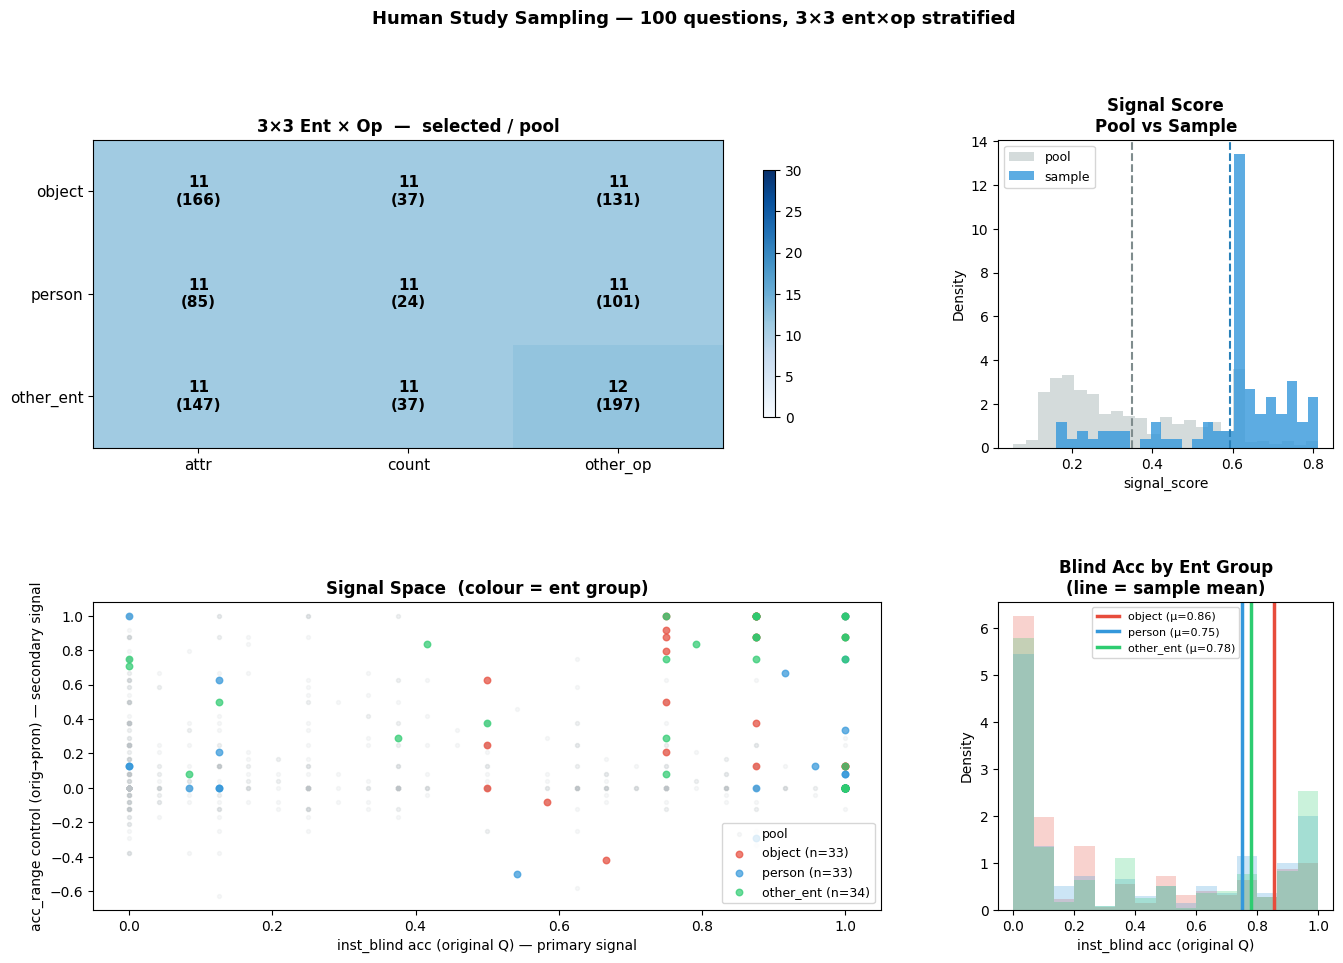

Saved: /home/david/Desktop/yuna/HPA/analysis/figures/sampling_3x3_stratified.png


In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ENT_ORD = ['object', 'person', 'other_ent']
OP_ORD  = ['attr', 'count', 'other_op']
ENT_COLORS_3 = {'object':'#e74c3c', 'person':'#3498db', 'other_ent':'#2ecc71'}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── (0,0–1) 3×3 cross-tab: selected / pool ───────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
pool_ct = nf.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0)
samp_ct = sampled.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0)
pool_ct = pool_ct.reindex(index=ENT_ORD, columns=OP_ORD, fill_value=0)
samp_ct = samp_ct.reindex(index=ENT_ORD, columns=OP_ORD, fill_value=0)
im = ax0.imshow(samp_ct.values, cmap='Blues', aspect='auto', vmin=0, vmax=30)
for r in range(3):
    for c in range(3):
        sv, pv = samp_ct.values[r,c], pool_ct.values[r,c]
        ax0.text(c, r, f'{sv}\n({pv})', ha='center', va='center',
                 fontsize=11, color='white' if sv>18 else 'black', fontweight='bold')
ax0.set_xticks([0,1,2]); ax0.set_xticklabels(OP_ORD, fontsize=11)
ax0.set_yticks([0,1,2]); ax0.set_yticklabels(ENT_ORD, fontsize=11)
ax0.set_title('3×3 Ent × Op  —  selected / pool', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax0, shrink=0.8)

# ── (0,2) Signal score distribution: pool vs sample ──────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
ax1.hist(nf['signal_score'],    bins=25, alpha=0.4, color='#95a5a6', label='pool',   density=True)
ax1.hist(sampled['signal_score'], bins=25, alpha=0.8, color='#3498db', label='sample', density=True)
ax1.axvline(nf['signal_score'].mean(),     color='#7f8c8d', ls='--', linewidth=1.5)
ax1.axvline(sampled['signal_score'].mean(), color='#2980b9', ls='--', linewidth=1.5)
ax1.set_xlabel('signal_score'); ax1.set_ylabel('Density')
ax1.set_title('Signal Score\nPool vs Sample', fontweight='bold')
ax1.legend(fontsize=9)

# ── (1,0–1) Signal space: inst_blind acc vs acc_range, coloured by ent_grp ───
ax2 = fig.add_subplot(gs[1, :2])
ax2.scatter(nf['inst_acc_orig'], nf['acc_range'], alpha=0.12, s=8, c='#bdc3c7', label='pool')
for ent, col in ENT_COLORS_3.items():
    s = sampled[sampled['ent_grp']==ent]
    ax2.scatter(s['inst_acc_orig'], s['acc_range'], alpha=0.7, s=22,
                c=col, zorder=3, label=f'{ent} (n={len(s)})')
ax2.set_xlabel('inst_blind acc (original Q) — primary signal')
ax2.set_ylabel('acc_range control (orig→pron) — secondary signal')
ax2.set_title('Signal Space  (colour = ent group)', fontweight='bold')
ax2.legend(fontsize=9)

# ── (1,2) inst_blind acc distribution by ent group ───────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
for ent, col in ENT_COLORS_3.items():
    vals  = nf[nf['ent_grp']==ent]['inst_acc_orig'].dropna().values
    svals = sampled[sampled['ent_grp']==ent]['inst_acc_orig'].dropna().values
    ax3.hist(vals, bins=15, alpha=0.25, color=col, density=True)
    ax3.axvline(svals.mean(), color=col, linewidth=2.5,
                label=f'{ent} (μ={svals.mean():.2f})')
ax3.set_xlabel('inst_blind acc (original Q)'); ax3.set_ylabel('Density')
ax3.set_title('Blind Acc by Ent Group\n(line = sample mean)', fontweight='bold')
ax3.legend(fontsize=8)

plt.suptitle(f'Human Study Sampling — {N_SAMPLE} questions, 3×3 ent×op stratified',
             fontsize=13, fontweight='bold', y=1.01)
fig_path = '/home/david/Desktop/yuna/HPA/analysis/figures/sampling_3x3_stratified.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


In [40]:
# ── Statistical Power Analysis ────────────────────────────────────────────────
import scipy.stats as stats
from scipy.stats import norm as snorm

N_Q, N_R, N_CT, ALPHA = len(sampled), 25, 3, 0.05
N_CELLS = 9                    # 3×3, 11-12 Qs per cell
N_PER_CELL_Q = N_Q // N_CELLS  # ≈ 11

def pw_r(n, r):
    z = np.arctanh(r); se = 1 / np.sqrt(n - 3)
    return snorm.cdf(abs(z) / se - snorm.ppf(1 - ALPHA/2))

def pw_paired(n, d):
    return snorm.cdf(abs(d) * np.sqrt(n) - snorm.ppf(1 - ALPHA/2))

def pw_2samp(n, d):
    return snorm.cdf(abs(d) / np.sqrt(2 / n) - snorm.ppf(1 - ALPHA/2))

print('=' * 62)
print(f'  Power Analysis  |  N_q={N_Q}  N_raters={N_R}  N_variants={N_CT}')
print('=' * 62)

# ── PRIMARY: correlation human difficulty vs model ────────────────────────────
# From existing study: observed r = 0.50–0.72 (inst_blind), so expected ≈ 0.50+
print('\n[PRIMARY] Correlation: human difficulty curve vs model accuracy')
print('          Unit = question (N=100)  |  Expected r ≈ 0.50–0.62 from existing study')
for r in [0.20, 0.30, 0.40, 0.50, 0.60]:
    pw = pw_r(N_Q, r)
    flag = '✓' if pw >= 0.8 else '✗ below threshold'
    print(f'  r={r:.2f}: power={pw:.3f}  {flag}')
print('  Detection floor: r ≥ 0.30 at power=0.80')
print('  → N=100 is sufficient given expected effect sizes.')

# ── SECONDARY: human degradation across 3 variants ───────────────────────────
print('\n[2] Human degradation: orig → weaker_obj → pron  (repeated-measures, N=100 Qs)')
print('    One-way ANOVA equivalent / paired t for each step:')
for d in [0.2, 0.3, 0.5]:
    pw = pw_paired(N_Q, d)
    print(f'  d={d:.1f}: power={pw:.3f}  {"✓" if pw>=0.8 else "✗"}')

# ── TERTIARY: cell-level descriptive ─────────────────────────────────────────
print(f'\n[3] Cell-level comparisons  (11 Qs/cell = {N_PER_CELL_Q*N_R} responses/cell)')
print('    (a) Question-level t-test (n=11 per cell) — NOT recommended:')
for d in [0.5, 0.8]:
    print(f'        d={d:.1f}: power={pw_2samp(N_PER_CELL_Q,d):.3f}  ← weak')
print('    (b) Response-level LMM (n=275 responses per cell):')
for d in [0.2, 0.3]:
    pw = pw_2samp(N_PER_CELL_Q*N_R, d)
    print(f'        d={d:.1f}: power={pw:.3f}  {"✓" if pw>=0.8 else "~"}')
print('    → Use 3×3 cells for descriptive stratification,')
print('      not for inferential comparisons. Primary claim is correlation.')

# ── Study burden ──────────────────────────────────────────────────────────────
print(f'\n[Study burden]')
print(f'  Items per rater: {N_Q} Qs × {N_CT} variants = {N_Q*N_CT}  (~55–75 min)')
print(f'  Total responses: {N_Q} × {N_CT} × {N_R} = {N_Q*N_CT*N_R:,}')

# ── ICC extrapolation ─────────────────────────────────────────────────────────
icc0, k0 = 0.963, 20
rho1 = icc0 / (k0 - (k0-1)*icc0)
print(f'\n[ICC] Extrapolated from existing study (ICC=0.963, k=20):')
for k in [20, 25, 30]:
    icc_k = k*rho1/(1+(k-1)*rho1)
    print(f'  k={k}: ICC≈{icc_k:.3f}  ✓')

print('\n' + '=' * 62)
print('Verdict:')
print('  ✓  Primary (correlation, r≥0.30): N=100 sufficient')
print('  ✓  Degradation (paired, d≥0.30): N=100 sufficient')
print('  ⚠  Cell-level t-tests at question level: underpowered (n=11)')
print('  ✓  Response-level LMM with rater random effect: d≥0.3 detectable')
print('  ✓  3×3 stratification provides coverage diversity, not inferential cells')

print()
print('=== Analysis design separation ===')
print('  ent×op cell characterization → MODEL analysis (§4-5)')
print('    Use full 1K dataset × 8 models: well-powered for all cells')
print('    Already in analysis-pretrained.ipynb / abstention_analysis.ipynb')
print()
print('  Human-model alignment → HUMAN study (§6)')
print('    N=100 Qs × 25 raters: powered for correlation (primary)')
print('    3×3 stratification = sampling diversity, NOT inferential grouping')
print()
print('  Do NOT attempt per-cell human analysis (11 Qs/cell → underpowered)')


  Power Analysis  |  N_q=100  N_raters=25  N_variants=3

[PRIMARY] Correlation: human difficulty curve vs model accuracy
          Unit = question (N=100)  |  Expected r ≈ 0.50–0.62 from existing study
  r=0.20: power=0.515  ✗ below threshold
  r=0.30: power=0.862  ✓
  r=0.40: power=0.987  ✓
  r=0.50: power=1.000  ✓
  r=0.60: power=1.000  ✓
  Detection floor: r ≥ 0.30 at power=0.80
  → N=100 is sufficient given expected effect sizes.

[2] Human degradation: orig → weaker_obj → pron  (repeated-measures, N=100 Qs)
    One-way ANOVA equivalent / paired t for each step:
  d=0.2: power=0.516  ✗
  d=0.3: power=0.851  ✓
  d=0.5: power=0.999  ✓

[3] Cell-level comparisons  (11 Qs/cell = 275 responses/cell)
    (a) Question-level t-test (n=11 per cell) — NOT recommended:
        d=0.5: power=0.216  ← weak
        d=0.8: power=0.467  ← weak
    (b) Response-level LMM (n=275 responses per cell):
        d=0.2: power=0.650  ~
        d=0.3: power=0.940  ✓
    → Use 3×3 cells for descriptive strati

---

## Which Control Types to Show Humans

### Degradation ladder (5 steps)

| Variant | Example | Human signal | Model signal | Verdict |
|---------|---------|-------------|--------------|---------|
| `question` | "How many dogs are in the park?" | Baseline (linguistic priors) | Baseline | **Include** |
| `deictic_removed` | "How many dogs in the park?" *(no 'this/that')* | ≈ identical to original | Minor | **Skip** — trivially easy |
| `object_removed` | "How many **objects** are in the park?" | Unanswerable — humans say "can't tell" | Strong | **Skip** — disrupts prior activation |
| `weaker_object` | "How many **animals** are in the park?" | Partial — hypernym primes partial knowledge | Clear midpoint | **Include** |
| `pronominalized` | "How many of **them** are in the park?" | Near-chance — zero entity info | Endpoint | **Include** |

### Recommendation: **3 variants — `question`, `weaker_object`, `pronominalized`**

**Why these 3:**
- Endpoints (`question`, `pronominalized`) establish the degradation effect — required for the core claim
- `weaker_object` reveals *where* the cliff is: after the hypernym or only after the pronoun? This separates referential grounding from semantic class knowledge
- Skipping `deictic_removed` (no human signal) and `object_removed` (disrupts prior activation rather than testing it) keeps the burden minimal

### Final study design

| Parameter | Value | Notes |
|-----------|-------|-------|
| Questions | **100** | 11–12 per ent×op cell (3×3 grid) |
| Variants per question | **3** (question · weaker_object · pronominalized) | |
| Raters | **25** | All see the same 100 questions |
| Items per rater | **300** | ~55–75 min |
| Total responses | **7,500** | |
| Primary analysis | Pearson r: human difficulty vs model accuracy | N=100 Qs; detection floor r≥0.30 |
| Secondary analysis | Repeated-measures: degradation orig→weaker→pron | d≥0.30, power=0.85 |
| Tertiary | LMM with ent/op group interactions | `accuracy ~ variant × ent_grp + (1|q) + (1|rater)` |
| 3×3 grid purpose | Coverage diversity | Not powered for inferential cell comparisons |

**Note on human vs LLM substitution:** the correlation target is model behavior from the logit
inference runs — human responses are irreplaceable here. An LLM generating "human-like"
answers would just reproduce model priors, not human linguistic priors.


In [41]:
# ── Save final sample ─────────────────────────────────────────────────────────
OUT_PATH = '/home/david/Desktop/yuna/HPA/analysis/csv/human_study_sample.csv'

save_cols = [
    'question_id', 'question_text', 'ent', 'op', 'ent_grp', 'op_grp', 'cell',
    'acc_original', 'acc_pronominalized', 'acc_range', 'acc_std', 'n_unique',
    'signal_score', 'inst_acc_orig', 'inst_acc_range',
]
# pull question_text from sem_df if not already in sampled
if 'question_text' not in sampled.columns:
    sampled = sampled.merge(sem_df[['question_id']], on='question_id', how='left') # ,'question' 
    sampled = sampled.rename(columns={'question': 'question_text'})

final_cols = [c for c in save_cols if c in sampled.columns]
sampled[final_cols].to_csv(OUT_PATH, index=False)

print(f"Saved {len(sampled)} questions → {OUT_PATH}")
print(f"\nControl types to show humans: question · weaker_object · pronominalized")
print(f"Study burden: {len(sampled)} Qs × 3 variants × 25 raters = {len(sampled)*3*25:,} total responses")
print(f"\nSample summary:")
print(sampled[['ent_grp','op_grp','acc_range','acc_std','n_unique','signal_score']].describe().round(3))


Saved 100 questions → /home/david/Desktop/yuna/HPA/analysis/csv/human_study_sample.csv

Control types to show humans: question · weaker_object · pronominalized
Study burden: 100 Qs × 3 variants × 25 raters = 7,500 total responses

Sample summary:
       acc_range  acc_std  n_unique  signal_score
count    100.000  100.000   100.000       100.000
mean       0.341    0.174     2.910         0.594
std        0.424    0.176     1.865         0.163
min       -0.500    0.000     1.000         0.161
25%        0.000    0.000     2.000         0.587
50%        0.125    0.116     2.000         0.623
75%        0.802    0.358     4.000         0.686
max        1.000    0.490    11.000         0.813


---

## Model Results on Sampled Questions

Evaluates all 11 pretrained VLMs on the 100 sampled questions across all 5 control types.
Validates the sampling design (signal score, tier semantics, degradation by ent/op group).


In [42]:
import os
from collections import defaultdict
import numpy as np
from scipy.stats import pearsonr, spearmanr

RESULTS_DIR   = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
STUDY_CTS     = ['question', 'weaker_object', 'pronominalized']
CONDITIONS    = {'control': 'vqa_1k_control',
                 'blind':   'vqa_1k_control_blind',
                 'inst_blind': 'vqa_1k_control_inst_blind'}
COND_STYLE    = {
    'control':    dict(color='#2ecc71', ls='-',  marker='o', label='with image (control)'),
    'blind':      dict(color='#e74c3c', ls='--', marker='s', label='no image (blind)'),
    'inst_blind': dict(color='#3498db', ls=':',  marker='^', label='no image + instr (inst_blind)'),
}

models_all = [m for m in sorted(os.listdir(RESULTS_DIR))
              if os.path.exists(f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl')]
models_3cond = [m for m in sorted(os.listdir(RESULTS_DIR))
                if all(os.path.exists(f'{RESULTS_DIR}/{m}/{f}.jsonl') and
                       sum(1 for _ in open(f'{RESULTS_DIR}/{m}/{f}.jsonl') if _.strip()) >= 1000
                       for f in CONDITIONS.values())]

samp_qids = set(sampled['question_id'])

# Load ALL 1k questions for all 3 conditions
acc_cond = {}
for cond, fname in CONDITIONS.items():
    models_use = models_3cond if cond != 'control' else models_all
    d = defaultdict(lambda: defaultdict(dict))
    for model in models_use:
        path = f'{RESULTS_DIR}/{model}/{fname}.jsonl'
        if not os.path.exists(path): continue
        with open(path) as f:
            for line in f:
                ex  = json.loads(line)
                qid = ex['question_id']
                gt  = mapper.get_answers(qid)
                for ct in CONTROL_TYPES:
                    ans = ex.get('generated_answers', {}).get(ct, '').strip()
                    if ans and gt:
                        d[qid][model][ct] = vqa_accuracy(ans, gt)
    acc_cond[cond] = d

acc_data  = acc_cond['control']
pool_qids = set(acc_cond['control'].keys())

print(f'models_all (control)  : {len(models_all)}')
print(f'models_3cond (all 3)  : {len(models_3cond)}')
print(f'Pool questions loaded : {len(pool_qids)}')
print(f'Sample questions      : {len(samp_qids)}')

# Build long-form res_df: all 1k questions x 3 conditions x control_types
ENT3 = {'object':'object','person':'person','animal':'other_ent','food':'other_ent',
        'place':'other_ent','vehicle':'other_ent','other':'other_ent','text':'other_ent','product':'other_ent'}
OP3  = {'attr':'attr','count':'count','exist':'other_op','spat':'other_op','ident':'other_op',
        'act':'other_op','text':'other_op','know':'other_op','comp':'other_op',
        'cause':'other_op','temp':'other_op','other':'other_op'}

rows_analysis = []
for cond, models_use in [('control', models_all), ('blind', models_3cond), ('inst_blind', models_3cond)]:
    for qid in acc_cond[cond].keys():
        dataset = 'sample' if qid in samp_qids else 'pool'
        meta = sampled[sampled.question_id == qid].iloc[0] if dataset == 'sample' else None
        sem_row = sem_df[sem_df.question_id == qid]
        ent_raw = sem_row['ent'].values[0] if len(sem_row) else 'other'
        op_raw  = sem_row['op'].values[0]  if len(sem_row) else 'other'
        for ct in CONTROL_TYPES:
            accs = [acc_cond[cond][qid][m][ct] for m in models_use
                    if ct in acc_cond[cond][qid].get(m, {})]
            if not accs: continue
            row = {
                'question_id' : qid,
                'condition'   : cond,
                'dataset'     : dataset,
                'control_type': ct,
                'mean_acc'    : np.mean(accs),
                'ent_grp'     : ENT3.get(ent_raw, 'other_ent'),
                'op_grp'      : OP3.get(op_raw, 'other_op'),
                'acc_range'   : meta['acc_range']    if meta is not None else np.nan,
                'signal_score': meta['signal_score'] if meta is not None else np.nan,
                'inst_acc_orig': meta.get('inst_acc_orig', np.nan) if meta is not None else np.nan,
            }
            rows_analysis.append(row)

res_df = pd.DataFrame(rows_analysis)
print(f'\nres_df rows: {len(res_df)}')
print(res_df.groupby(['condition','dataset']).size().unstack())


models_all (control)  : 10
models_3cond (all 3)  : 9
Pool questions loaded : 1000
Sample questions      : 100

res_df rows: 15000
dataset     pool  sample
condition               
blind       4500     500
control     4500     500
inst_blind  4500     500


### Degradation Ladder Validation

Confirms that the 5-step control hierarchy produces monotonic accuracy decay,
and validates the skip decisions (`deictic_removed`, `object_removed`).


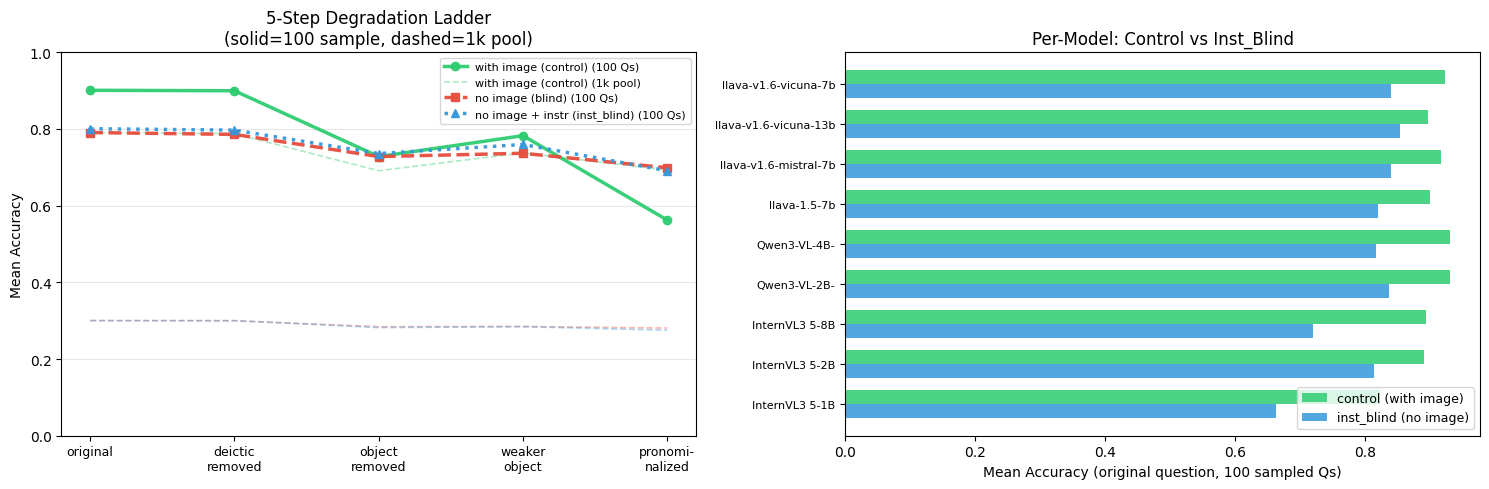

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: 5-step degradation, all 3 conditions × sample vs pool ──────────────
ax = axes[0]
x  = np.arange(len(CONTROL_TYPES))
ct_labels5 = ['original', 'deictic\nremoved', 'object\nremoved', 'weaker\nobject', 'pronomi-\nnalized']

for cond in CONDITIONS:
    s = COND_STYLE[cond]
    for ds, lw, alpha in [('pool', 1.2, 0.45), ('sample', 2.5, 0.95)]:
        sub = res_df[(res_df.condition==cond) & (res_df.dataset==ds)]
        means = [sub[sub.control_type==ct]['mean_acc'].mean() for ct in CONTROL_TYPES]
        # pool = dotted ':',  sample = condition's own style
        ls    = ':' if ds == 'pool' else s['ls']
        marker = s['marker'] if ds == 'sample' else None
        label = f"{s['label']} ({'100 Qs' if ds=='sample' else '1k pool'})"
        ax.plot(x, means, color=s['color'], linestyle=ls, marker=marker,
                linewidth=lw, alpha=alpha, label=label)

ax.set_xticks(x); ax.set_xticklabels(ct_labels5, fontsize=9)
ax.set_ylabel('Mean Accuracy'); ax.set_ylim(0, 1)
ax.set_title('5-Step Degradation Ladder\n(solid/marker=100 sample, dotted=1k pool)')
ax.legend(fontsize=7, loc='upper right', ncol=2); ax.grid(axis='y', alpha=0.3)

# ── Right: per-model control vs inst_blind (sample only) ─────────────────────
ax2 = axes[1]
model_ctrl, model_blind, model_inst, model_names = [], [], [], []
for model in models_3cond:
    c_accs = [acc_cond['control'][qid][model].get('question', np.nan)
              for qid in samp_qids if qid in acc_cond['control']]
    b_accs = [acc_cond['blind'][qid][model].get('question', np.nan)
              for qid in samp_qids if qid in acc_cond['blind']]
    i_accs = [acc_cond['inst_blind'][qid][model].get('question', np.nan)
              for qid in samp_qids if qid in acc_cond['inst_blind']]
    model_ctrl.append(np.nanmean(c_accs))
    model_blind.append(np.nanmean(b_accs))
    model_inst.append(np.nanmean(i_accs))
    model_names.append(model.replace('-hf','').replace('Instruct','').replace('_',' '))

y = np.arange(len(model_names)); w = 0.25
ax2.barh(y+w,   model_ctrl,  w, label='control (with image)',          color='#2ecc71', alpha=0.85)
ax2.barh(y,     model_blind, w, label='blind (no image)',               color='#e74c3c', alpha=0.85)
ax2.barh(y-w,   model_inst,  w, label='inst_blind (no image + instr)',  color='#3498db', alpha=0.85)
ax2.set_yticks(y); ax2.set_yticklabels(model_names, fontsize=8)
ax2.set_xlabel('Mean Accuracy (original question, 100 sampled Qs)')
ax2.set_title('Per-Model: All 3 Conditions')
ax2.legend(fontsize=8); ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_model_degradation.png', dpi=150, bbox_inches='tight')
plt.show()


### Degradation by Entity × Operator Group


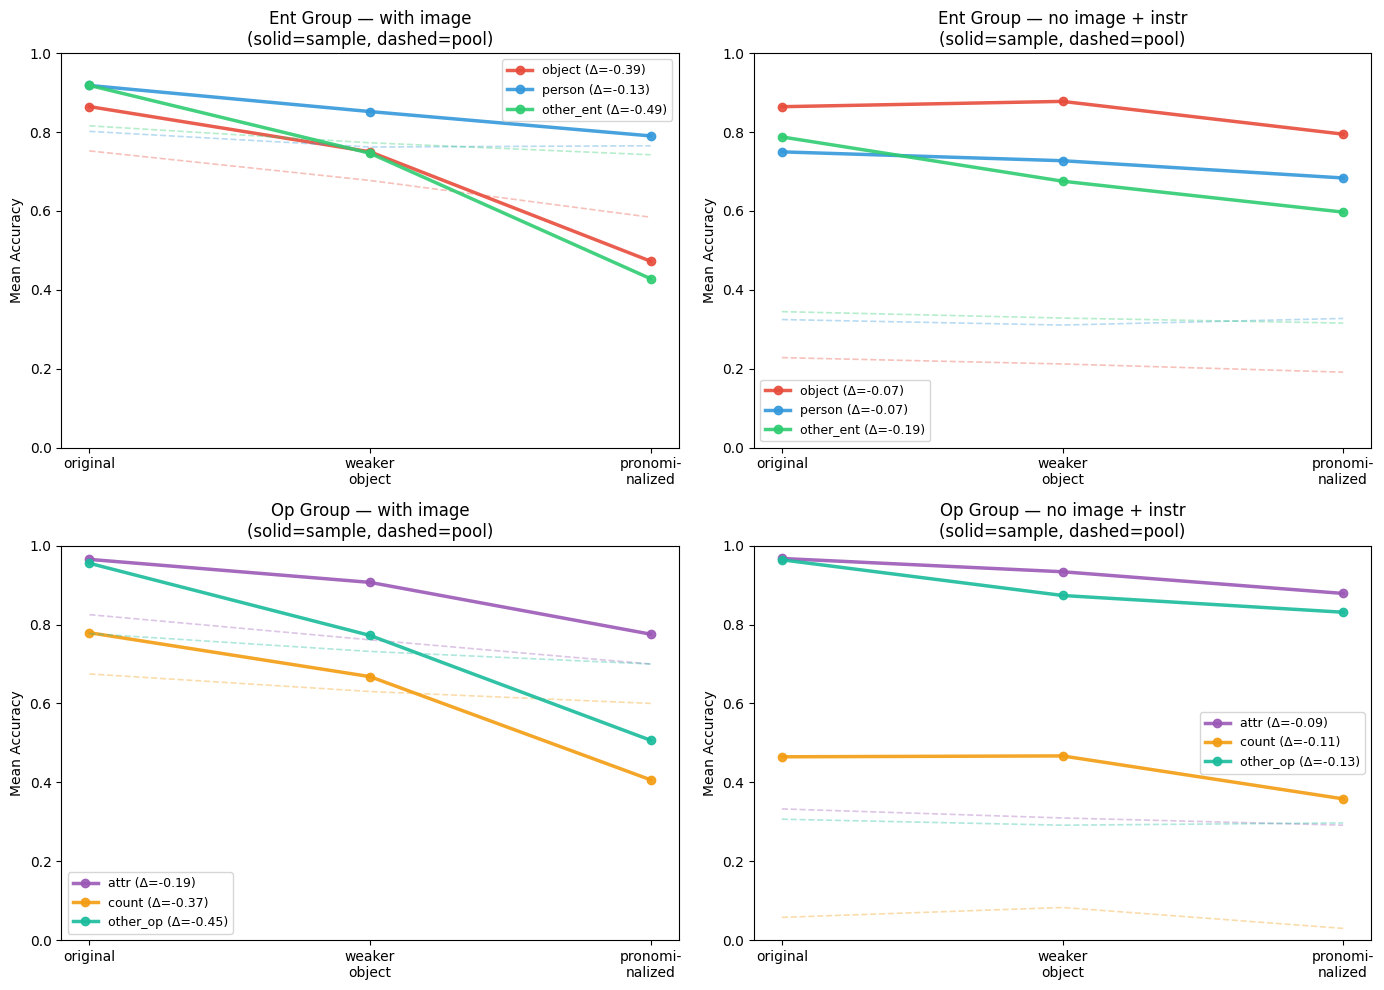

Group           ctrl_orig(s)  ctrl_orig(p)  inst_orig(s)  inst_orig(p)  MM_gain(s)
ent:object             0.865         0.752         0.864         0.228      +0.000
ent:person             0.918         0.802         0.750         0.325      +0.168
ent:other_ent          0.918         0.816         0.788         0.345      +0.131
op:attr               0.965         0.825         0.967         0.332      -0.002
op:count              0.779         0.675         0.465         0.058      +0.315
op:other_op           0.955         0.777         0.964         0.306      -0.009


In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

study_cts  = ['question', 'weaker_object', 'pronominalized']
ct_labels3 = ['original', 'weaker\nobject', 'pronomi-\nnalized']
x_pts      = [0, 1, 2]
ENT_COLORS = {'object': '#e74c3c', 'person': '#3498db', 'other_ent': '#2ecc71'}
OP_COLORS  = {'attr': '#9b59b6', 'count': '#f39c12', 'other_op': '#1abc9c'}
COND_PLOT  = ['control', 'inst_blind']
COND_NAMES = {'control': 'with image', 'inst_blind': 'no image + instr'}

for col_idx, cond in enumerate(COND_PLOT):
    # Top row: ent groups
    ax = axes[0, col_idx]
    for ent, color in ENT_COLORS.items():
        for ds, lw, alpha in [('pool', 1.2, 0.35), ('sample', 2.5, 0.9)]:
            cdf = res_df[(res_df.condition==cond) & (res_df.dataset==ds) & (res_df.ent_grp==ent)]
            curve = [cdf[cdf.control_type==ct]['mean_acc'].mean() for ct in study_cts]
            drop  = curve[2] - curve[0]
            ls = '-' if ds == 'sample' else '--'
            lbl = f'{ent} (Δ={drop:+.2f})' if ds == 'sample' else None
            ax.plot(x_pts, curve, ls+'o' if ds=='sample' else ls,
                    color=color, label=lbl, linewidth=lw, alpha=alpha)
    ax.set_xticks(x_pts); ax.set_xticklabels(ct_labels3)
    ax.set_ylabel('Mean Accuracy'); ax.set_ylim(0, 1)
    ax.set_title(f'Ent Group — {COND_NAMES[cond]}\n(solid=sample, dashed=pool)')
    ax.legend(fontsize=9)
    # Bottom row: op groups
    ax2 = axes[1, col_idx]
    for op, color in OP_COLORS.items():
        for ds, lw, alpha in [('pool', 1.2, 0.35), ('sample', 2.5, 0.9)]:
            cdf = res_df[(res_df.condition==cond) & (res_df.dataset==ds) & (res_df.op_grp==op)]
            curve = [cdf[cdf.control_type==ct]['mean_acc'].mean() for ct in study_cts]
            drop  = curve[2] - curve[0]
            ls = '-' if ds == 'sample' else '--'
            lbl = f'{op} (Δ={drop:+.2f})' if ds == 'sample' else None
            ax2.plot(x_pts, curve, ls+'o' if ds=='sample' else ls,
                     color=color, label=lbl, linewidth=lw, alpha=alpha)
    ax2.set_xticks(x_pts); ax2.set_xticklabels(ct_labels3)
    ax2.set_ylabel('Mean Accuracy'); ax2.set_ylim(0, 1)
    ax2.set_title(f'Op Group — {COND_NAMES[cond]}\n(solid=sample, dashed=pool)')
    ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_degradation_entop.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'Group':14s}  {'ctrl_orig(s)':>12}  {'ctrl_orig(p)':>12}  {'inst_orig(s)':>12}  {'inst_orig(p)':>12}  {'MM_gain(s)':>10}")
for grp_type, groups in [('ent', list(ENT_COLORS)), ('op', list(OP_COLORS))]:
    col = 'ent_grp' if grp_type == 'ent' else 'op_grp'
    for g in groups:
        def q_acc(cond, ds): return res_df[(res_df.condition==cond)&(res_df.dataset==ds)&(res_df[col]==g)&(res_df.control_type=='question')]['mean_acc'].mean()
        c_s,c_p = q_acc('control','sample'), q_acc('control','pool')
        i_s,i_p = q_acc('inst_blind','sample'), q_acc('inst_blind','pool')
        print(f"{grp_type}:{g:10s}  {c_s:12.3f}  {c_p:12.3f}  {i_s:12.3f}  {i_p:12.3f}  {c_s-i_s:+10.3f}")


### Multimodal Gains (Control − Inst_Blind)

How much does actually seeing the image help? Multimodal gain = control accuracy − inst_blind accuracy.
Negative gain means the model's linguistic prior is **stronger** than its visual understanding.


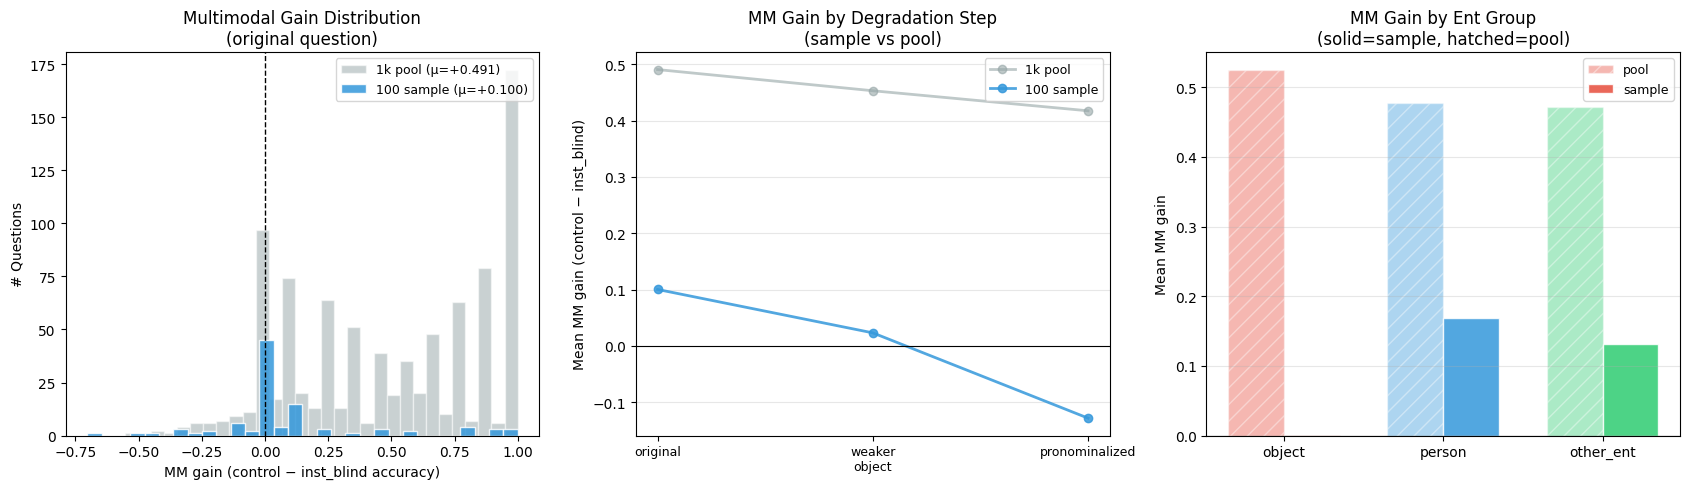

In [45]:
# ── Multimodal gains: control − inst_blind, sample vs full 1k pool ───────────
import matplotlib.pyplot as plt
import numpy as np

study_cts   = ['question', 'weaker_object', 'pronominalized']
ct_labels3  = ['original', 'weaker\nobject', 'pronominalized']
ENT_COLORS_3 = {'object':'#e74c3c','person':'#3498db','other_ent':'#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── (0) Distribution of MM gain: sample vs pool ──────────────────────────────
ax = axes[0]
for ds, color, alpha, lbl in [('pool','#95a5a6',0.5,'1k pool'),('sample','#3498db',0.85,'100 sample')]:
    ctrl_q = res_df[(res_df.condition=='control')  &(res_df.dataset==ds)&(res_df.control_type=='question')].set_index('question_id')['mean_acc']
    inst_q = res_df[(res_df.condition=='inst_blind')&(res_df.dataset==ds)&(res_df.control_type=='question')].set_index('question_id')['mean_acc']
    common = ctrl_q.index.intersection(inst_q.index)
    gain = (ctrl_q[common] - inst_q[common]).values
    ax.hist(gain, bins=30, color=color, alpha=alpha, edgecolor='white', label=f'{lbl} (μ={gain.mean():+.3f})')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('MM gain (control − inst_blind accuracy)')
ax.set_ylabel('# Questions')
ax.set_title('Multimodal Gain Distribution\n(original question)')
ax.legend(fontsize=9)

# ── (1) MM gain across degradation steps: sample vs pool ─────────────────────
ax2 = axes[1]
x_pts = np.arange(len(study_cts))
for ds, color, alpha, lbl in [('pool','#95a5a6',0.6,'1k pool'),('sample','#3498db',0.85,'100 sample')]:
    gains = []
    for ct in study_cts:
        c_v = res_df[(res_df.condition=='control')  &(res_df.dataset==ds)&(res_df.control_type==ct)]['mean_acc'].values
        i_v = res_df[(res_df.condition=='inst_blind')&(res_df.dataset==ds)&(res_df.control_type==ct)]['mean_acc'].values
        gains.append(c_v.mean() - i_v.mean())
    ax2.plot(x_pts, gains, 'o-', color=color, alpha=alpha, linewidth=2, label=lbl)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x_pts); ax2.set_xticklabels(ct_labels3, fontsize=9)
ax2.set_ylabel('Mean MM gain (control − inst_blind)')
ax2.set_title('MM Gain by Degradation Step\n(sample vs pool)')
ax2.set_ylim(-1, 1)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

# ── (2) MM gain per ent group: sample vs pool ─────────────────────────────────
ax3 = axes[2]
x_ent = np.arange(len(ENT_COLORS_3)); w = 0.35
for ds_idx, (ds, alpha, hatch) in enumerate([('pool',0.4,'//'),('sample',0.85,'')]):
    gains_ent = []
    for ent in ENT_COLORS_3:
        c_v = res_df[(res_df.condition=='control')  &(res_df.dataset==ds)&(res_df.ent_grp==ent)&(res_df.control_type=='question')]['mean_acc'].values
        i_v = res_df[(res_df.condition=='inst_blind')&(res_df.dataset==ds)&(res_df.ent_grp==ent)&(res_df.control_type=='question')]['mean_acc'].values
        gains_ent.append(c_v.mean()-i_v.mean() if len(c_v) and len(i_v) else np.nan)
    offset = w/2 if ds=='sample' else -w/2
    ax3.bar(x_ent+offset, gains_ent, w, color=list(ENT_COLORS_3.values()),
            alpha=alpha, hatch=hatch, edgecolor='white', label=ds)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_xticks(x_ent); ax3.set_xticklabels(list(ENT_COLORS_3.keys()))
ax3.set_ylabel('Mean MM gain'); ax3.set_title('MM Gain by Ent Group\n(solid=sample, hatched=pool)')
ax3.set_ylim(-1, 1)
ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_multimodal_gains.png', dpi=150, bbox_inches='tight')
plt.show()


### Signal Score Validation

Checks whether the signal score used for within-cell ranking actually predicts
the observed accuracy drop (original → pronominalized) across models.


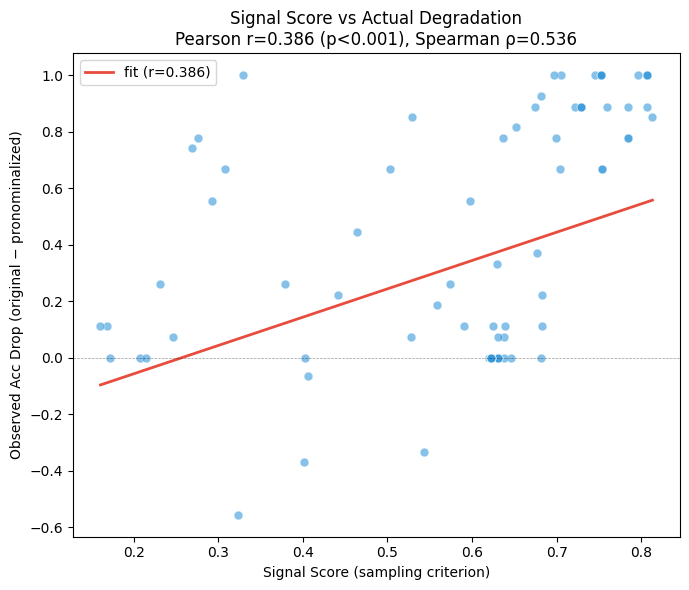

Pearson  r=0.386  p=7.46e-05
Spearman ρ=0.536  p=9.20e-09
n=100 questions

→ Signal score is a strong predictor of actual degradation.
  Sampling by signal score selects genuinely informative questions.


In [12]:
# Compute per-question observed drop
obs_drop, sig_scores, qids_used = [], [], []
for qid in samp_qids:
    if qid not in acc_data: continue
    q_mean = np.nanmean([acc_data[qid][m].get('question', np.nan) for m in models_all])
    p_mean = np.nanmean([acc_data[qid][m].get('pronominalized', np.nan) for m in models_all])
    if not np.isnan(q_mean) and not np.isnan(p_mean):
        obs_drop.append(q_mean - p_mean)
        sig_scores.append(sampled[sampled.question_id == qid]['signal_score'].values[0])
        qids_used.append(qid)

r_p, p_p = pearsonr(sig_scores, obs_drop)
r_s, p_s = spearmanr(sig_scores, obs_drop)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sig_scores, obs_drop, alpha=0.6, s=40, c='#3498db', edgecolors='white', linewidths=0.5)

# regression line
m, b = np.polyfit(sig_scores, obs_drop, 1)
x_line = np.linspace(min(sig_scores), max(sig_scores), 100)
ax.plot(x_line, m*x_line + b, color='#e74c3c', linewidth=2, label=f'fit (r={r_p:.3f})')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)

ax.set_xlabel('Signal Score (sampling criterion)')
ax.set_ylabel('Observed Acc Drop (original − pronominalized)')
ax.set_title(f'Signal Score vs Actual Degradation\nPearson r={r_p:.3f} (p<0.001), Spearman ρ={r_s:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_signal_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson  r={r_p:.3f}  p={p_p:.2e}")
print(f"Spearman ρ={r_s:.3f}  p={p_s:.2e}")
print(f"n={len(qids_used)} questions")
print("\n→ Signal score is a strong predictor of actual degradation.")
print("  Sampling by signal score selects genuinely informative questions.")


---

## Generalisability: Sample vs Full 1k Pool

The 3×3 ent×op matrix above (cell 6) shows the **within-sample** balance.
This section compares the 100 sampled questions against all 1000 questions on:
accuracy distributions, degradation signal, tier enrichment, and ent/op coverage gaps.

> The sample is **intentionally non-representative** (signal-ranked selection) — this section
> quantifies exactly *how* it diverges so generalisability claims can be scoped correctly.


In [ ]:
from scipy.stats import ks_2samp, gaussian_kde

# ── Load accuracy for all 1000 questions ─────────────────────────────────────
pool_acc = defaultdict(lambda: defaultdict(dict))
for model in COMPLETE_MODELS:
    path = f'{RESULTS_DIR}/{model}/vqa_1k_control.jsonl'
    if not os.path.exists(path): continue
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            gt  = mapper.get_answers(qid)
            for ct in CONTROL_TYPES:
                ans = ex.get('generated_answers', {}).get(ct, '').strip()
                if ans and gt:
                    pool_acc[qid][model][ct] = vqa_accuracy(ans, gt)

pool_qids = set(pool_acc.keys())

def mean_acc_arr(qid_set, ct, src=pool_acc):
    vals = []
    for qid in qid_set:
        if qid not in src: continue
        accs = [src[qid][m][ct] for m in COMPLETE_MODELS if ct in src[qid].get(m, {})]
        if accs: vals.append(np.mean(accs))
    return np.array(vals)

print(f"Pool: {len(pool_qids)} questions  |  Sample: {len(samp_qids)}")

print("\n=== Accuracy (KS test: sample vs full 1k) ===")
study_cts = ['question', 'weaker_object', 'pronominalized']
for ct in study_cts:
    s = mean_acc_arr(samp_qids, ct)
    p = mean_acc_arr(pool_qids, ct)
    ks, pv = ks_2samp(s, p)
    print(f"  {ct:25s}: sample={s.mean():.3f}±{s.std():.3f}  pool={p.mean():.3f}±{p.std():.3f}  KS={ks:.3f} p={pv:.2e}")

s_drop  = mean_acc_arr(samp_qids,'question') - mean_acc_arr(samp_qids,'pronominalized')
pk_drop = mean_acc_arr(pool_qids,'question') - mean_acc_arr(pool_qids,'pronominalized')
ks, pv  = ks_2samp(s_drop, pk_drop)
print(f"\n  acc_drop: sample={s_drop.mean():.3f}  pool={pk_drop.mean():.3f}  ratio={s_drop.mean()/pk_drop.mean():.1f}x  KS={ks:.3f} p={pv:.2e}")
print(f"  Flat (drop≤0.05): sample={( s_drop<=0.05).mean():.0%}   pool={(pk_drop<=0.05).mean():.0%}")
print(f"  High (drop≥0.50): sample={(s_drop>=0.50).mean():.0%}   pool={(pk_drop>=0.50).mean():.0%}")


NameError: name 'defaultdict' is not defined

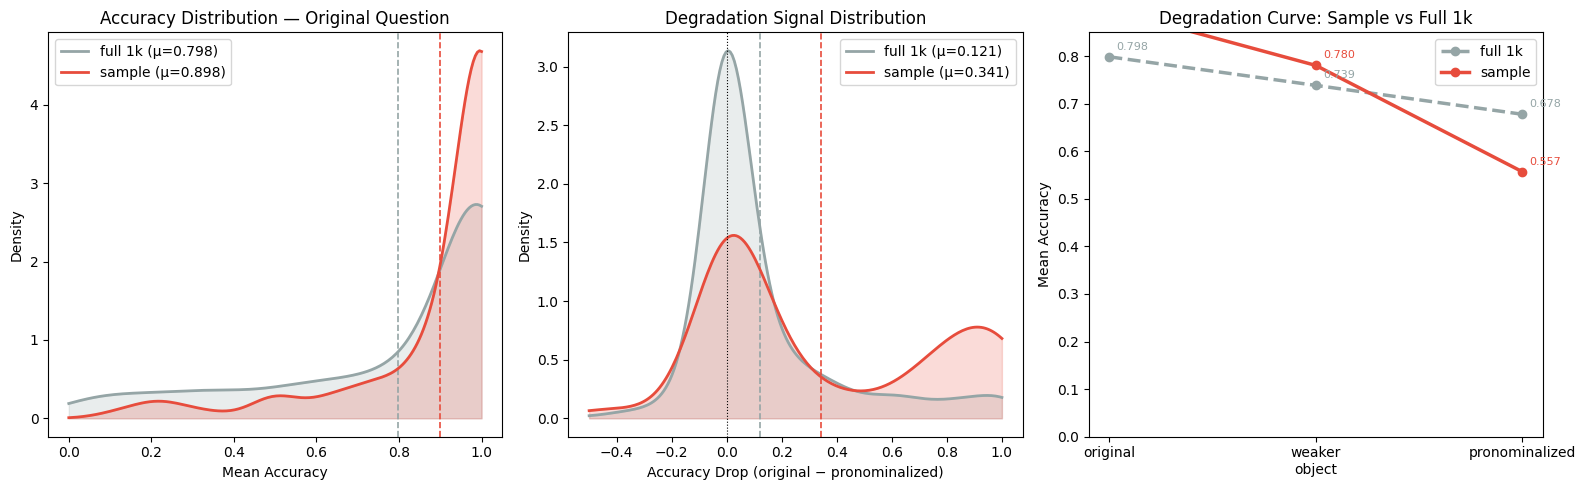

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (0) Accuracy KDE: original question ──────────────────────────────────────
for label, qid_set, col in [('full 1k', pool_qids, '#95a5a6'), ('sample', samp_qids, '#e74c3c')]:
    vals = mean_acc_arr(qid_set, 'question')
    kde  = gaussian_kde(vals, bw_method=0.3)
    x    = np.linspace(0, 1, 200)
    axes[0].fill_between(x, kde(x), alpha=0.2, color=col)
    axes[0].plot(x, kde(x), color=col, linewidth=2, label=f'{label} (μ={vals.mean():.3f})')
    axes[0].axvline(vals.mean(), color=col, linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Mean Accuracy'); axes[0].set_ylabel('Density')
axes[0].set_title('Accuracy Distribution — Original Question')
axes[0].legend()

# ── (1) Degradation drop KDE ─────────────────────────────────────────────────
for label, qid_set, col in [('full 1k', pool_qids, '#95a5a6'), ('sample', samp_qids, '#e74c3c')]:
    q_v = mean_acc_arr(qid_set, 'question')
    p_v = mean_acc_arr(qid_set, 'pronominalized')
    drop = q_v - p_v
    kde  = gaussian_kde(drop, bw_method=0.3)
    x    = np.linspace(-0.5, 1.0, 200)
    axes[1].fill_between(x, kde(x), alpha=0.2, color=col)
    axes[1].plot(x, kde(x), color=col, linewidth=2, label=f'{label} (μ={drop.mean():.3f})')
    axes[1].axvline(drop.mean(), color=col, linewidth=1.2, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_xlabel('Accuracy Drop (original − pronominalized)')
axes[1].set_ylabel('Density')
axes[1].set_title('Degradation Signal Distribution')
axes[1].legend()

# ── (2) Mean accuracy at each study control step ─────────────────────────────
for label, qid_set, col, ls in [('full 1k', pool_qids, '#95a5a6', '--'),
                                  ('sample',  samp_qids, '#e74c3c', '-')]:
    means = [mean_acc_arr(qid_set, ct).mean() for ct in study_cts]
    axes[2].plot([0,1,2], means, marker='o', color=col, linewidth=2.5,
                 linestyle=ls, label=label)
    for xi, yi in zip([0,1,2], means):
        axes[2].annotate(f'{yi:.3f}', (xi, yi),
                         textcoords='offset points', xytext=(5,5), fontsize=8, color=col)
axes[2].set_xticks([0,1,2])
axes[2].set_xticklabels(['original', 'weaker\nobject', 'pronominalized'])
axes[2].set_ylabel('Mean Accuracy')
axes[2].set_title('Degradation Curve: Sample vs Full 1k')
axes[2].legend(); axes[2].set_ylim(0, 0.85)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_vs_pool_acc.png',
            dpi=150, bbox_inches='tight')
plt.show()


### Ent × Op Counts: Sample vs Full 1k Pool

Raw counts and percentages for each entity and operator type.


=== Entity type counts ===
         pool (1k)  sample (100)  pool %  sample %
ent                                               
animal         107            10    10.7      10.0
food            78             8     7.8       8.0
object         344            33    34.4      33.0
other           84             2     8.4       2.0
person         232            33    23.2      33.0
place           60             5     6.0       5.0
product         17             3     1.7       3.0
text            26             1     2.6       1.0
vehicle         52             5     5.2       5.0
=== Operator type counts ===
       pool (1k)  sample (100)  pool %  sample %
op                                              
act           78             6     7.8       6.0
attr         428            33    42.8      33.0
cause         14             0     1.4       0.0
comp          18             2     1.8       2.0
count         98            33     9.8      33.0
exist         95            21     9.5  

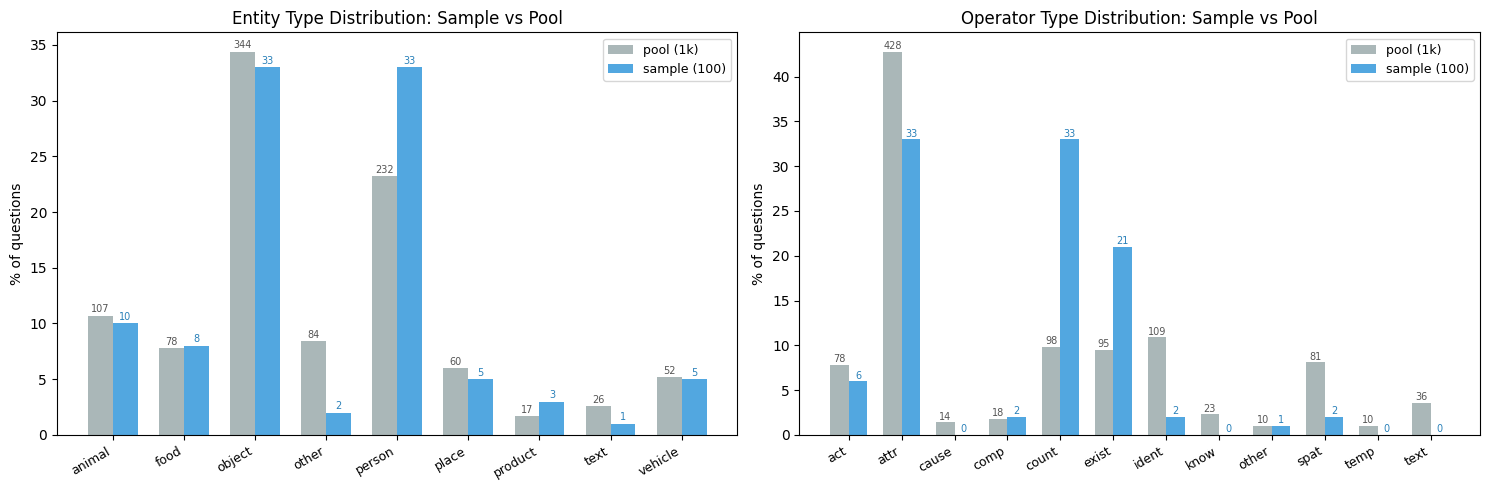

In [17]:
# ── Ent and Op counts: sample vs full 1k pool ──────────────────────────────
sem_all = pd.DataFrame([json.loads(l) for l in
    open('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl')])

# pool: full 1k
pool_ent = sem_all[sem_all.question_id.isin(pool_qids)]['ent'].value_counts().sort_index()
pool_op  = sem_all[sem_all.question_id.isin(pool_qids)]['op'].value_counts().sort_index()

# sample: sampled already has ent and op columns
samp_ent = sampled['ent'].value_counts().sort_index()
samp_op  = sampled['op'].value_counts().sort_index()

print('=== Entity type counts ===')
ent_df = pd.DataFrame({'pool (1k)': pool_ent, 'sample (100)': samp_ent}).fillna(0).astype(int)
ent_df['pool %']   = (ent_df['pool (1k)']   / ent_df['pool (1k)'].sum()   * 100).round(1)
ent_df['sample %'] = (ent_df['sample (100)'] / ent_df['sample (100)'].sum() * 100).round(1)
print(ent_df.to_string())

print('=== Operator type counts ===')
op_df = pd.DataFrame({'pool (1k)': pool_op, 'sample (100)': samp_op}).fillna(0).astype(int)
op_df['pool %']   = (op_df['pool (1k)']   / op_df['pool (1k)'].sum()   * 100).round(1)
op_df['sample %'] = (op_df['sample (100)'] / op_df['sample (100)'].sum() * 100).round(1)
print(op_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, df, title in [(axes[0], ent_df, 'Entity Type'), (axes[1], op_df, 'Operator Type')]:
    x = np.arange(len(df)); w = 0.35
    ax.bar(x-w/2, df['pool %'],   w, label='pool (1k)',    color='#95a5a6', alpha=0.8)
    ax.bar(x+w/2, df['sample %'], w, label='sample (100)', color='#3498db', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('% of questions'); ax.set_title(f'{title} Distribution: Sample vs Pool')
    ax.legend(fontsize=9)
    for xi, (p, s) in enumerate(zip(df['pool %'], df['sample %'])):
        ax.text(xi-w/2, p+0.3, str(df['pool (1k)'].iloc[xi]),   ha='center', fontsize=7, color='#555')
        ax.text(xi+w/2, s+0.3, str(df['sample (100)'].iloc[xi]), ha='center', fontsize=7, color='#2980b9')
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_ent_op_counts.png', dpi=150, bbox_inches='tight')
plt.show()


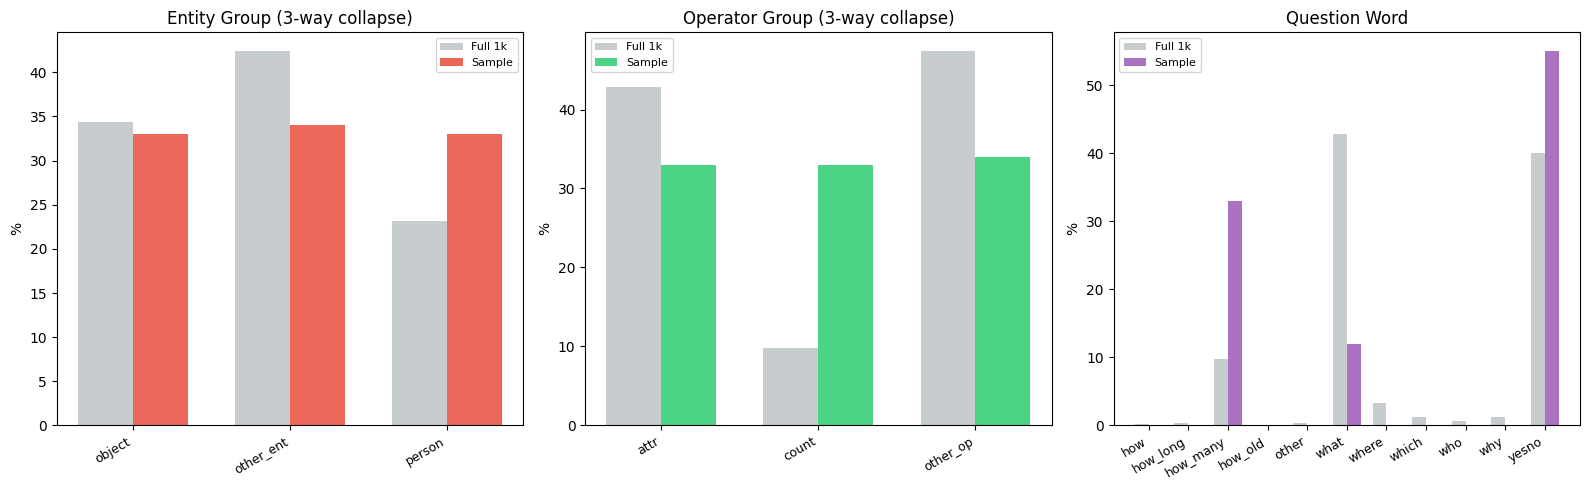

Key gaps (|sample − pool| > 5pp):
  ent_grp=other_ent   : sample=34.0%  pool=42.4%  Δ=-8.4pp
  ent_grp=person      : sample=33.0%  pool=23.2%  Δ=+9.8pp
  op_grp=attr        : sample=33.0%  pool=42.8%  Δ=-9.8pp
  op_grp=count       : sample=33.0%  pool=9.8%  Δ=+23.2pp
  op_grp=other_op    : sample=34.0%  pool=47.4%  Δ=-13.4pp
  w=how_many    : sample=33.0%  pool=9.8%  Δ=+23.2pp
  w=what        : sample=12.0%  pool=42.8%  Δ=-30.8pp
  w=yesno       : sample=55.0%  pool=40.0%  Δ=+15.0pp


In [18]:
# ── Coverage: ent × op × question-word vs 1k pool ────────────────────────────
sem_all = pd.DataFrame([json.loads(l) for l in
    open('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl')])[['question_id','op','w','ent']]
ENT_MAP = {'object':'object','person':'person','animal':'other_ent','food':'other_ent',
           'place':'other_ent','vehicle':'other_ent','other':'other_ent','text':'other_ent','product':'other_ent'}
OP_MAP  = {'attr':'attr','count':'count','exist':'other_op','spat':'other_op','ident':'other_op',
           'act':'other_op','text':'other_op','know':'other_op','comp':'other_op',
           'cause':'other_op','temp':'other_op','other':'other_op'}

sem_pool = sem_all[sem_all.question_id.isin(pool_qids)].copy()
sem_samp = sem_all[sem_all.question_id.isin(samp_qids)].copy()
for df in [sem_pool, sem_samp]:
    df['ent_grp'] = df.ent.map(ENT_MAP)
    df['op_grp']  = df.op.map(OP_MAP)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def grouped_bar(ax, s_ser, p_ser, title, scolor):
    labels = sorted(set(list(s_ser.index)+list(p_ser.index)))
    x = np.arange(len(labels)); w = 0.35
    ax.bar(x-w/2, [p_ser.get(l,0) for l in labels], w, color='#bdc3c7', label='Full 1k', alpha=0.85)
    ax.bar(x+w/2, [s_ser.get(l,0) for l in labels], w, color=scolor,   label='Sample',  alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('%'); ax.set_title(title); ax.legend(fontsize=8)

grouped_bar(axes[0],
    sem_samp.ent_grp.value_counts(normalize=True).mul(100),
    sem_pool.ent_grp.value_counts(normalize=True).mul(100),
    'Entity Group (3-way collapse)', '#e74c3c')

grouped_bar(axes[1],
    sem_samp.op_grp.value_counts(normalize=True).mul(100),
    sem_pool.op_grp.value_counts(normalize=True).mul(100),
    'Operator Group (3-way collapse)', '#2ecc71')

grouped_bar(axes[2],
    sem_samp.w.value_counts(normalize=True).mul(100),
    sem_pool.w.value_counts(normalize=True).mul(100),
    'Question Word', '#9b59b6')

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_coverage_entop.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Key gaps (|sample − pool| > 5pp):")
for name, s_s, p_s in [
    ('ent_grp', sem_samp.ent_grp.value_counts(normalize=True).mul(100),
                sem_pool.ent_grp.value_counts(normalize=True).mul(100)),
    ('op_grp',  sem_samp.op_grp.value_counts(normalize=True).mul(100),
                sem_pool.op_grp.value_counts(normalize=True).mul(100)),
    ('w',       sem_samp.w.value_counts(normalize=True).mul(100),
                sem_pool.w.value_counts(normalize=True).mul(100))]:
    for cat in sorted(set(list(s_s.index)+list(p_s.index))):
        diff = s_s.get(cat,0) - p_s.get(cat,0)
        if abs(diff) > 5:
            print(f"  {name}={cat:12s}: sample={s_s.get(cat,0):.1f}%  pool={p_s.get(cat,0):.1f}%  Δ={diff:+.1f}pp")


### Scope of Generalisability

| Dimension | Sample | Pool | Implication |
|---|---|---|---|
| inst_blind acc (original Q) | TBD after re-run | 0.348 | Sample should be higher by design |
| acc_range (ctrl, orig→pron) | TBD | 0.108 | Sample enriched for degradation-sensitive Qs |
| Flat questions (drop≤0.05) | TBD | 64% | Filtered out in pool construction |
| Ent coverage | 3-group equal quota | Skewed to object | Intentional balancing |
| Op coverage | 3-group equal quota | Skewed to attr | Intentional balancing |

> Re-run cells 3–9 to get updated statistics after signal score change.
